In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
from scipy.optimize import curve_fit
#debug
from scipy import stats


# URL do arquivo CSV inicial
url_init = 'https://raw.githubusercontent.com/profdanielrsousa/datasets_mackenzie/refs/heads/main/ensaio.csv'

try:
    # Carregar o arquivo CSV inicial
    df_index = pd.read_csv(url_init)
except Exception as e:
    print(f"Erro ao carregar o arquivo CSV inicial: {e}")
    exit(1)

# Ordenar o DataFrame pelo valor da coluna 'Vrms (V)'
df_index = df_index.sort_values(by='Vrms (V)')
df_index['Arquivo'] = df_index['Arquivo'].str.replace('*', '', regex=False)

# Inicializar arrays para armazenar os dados finais
temperatura = np.array([])
tensao = np.array([])
tensao_real = np.array([])
desvio_padrao = np.array([])
equacoes = np.array([])

quantidade_arquivos = 23 # alterar pra 23 depois

# Loop para processar cada arquivo listado no DataFrame
for i in range(quantidade_arquivos):
    try:
        nome_arquivo = df_index['Arquivo'].iloc[i]
        url = 'https://raw.githubusercontent.com/profdanielrsousa/datasets_mackenzie/refs/heads/main/' + nome_arquivo + 'CSV'

        try:
            # Carregar o arquivo CSV específico
            df = pd.read_csv(url, header=None, names=['tempo', 'ch1', 'ch1_pico'], skiprows=16, nrows=125000)
        except Exception as e:
            print(f"Erro ao carregar o arquivo CSV {nome_arquivo}: {e}")
            continue

        x = df['tempo']
        y = df['ch1']

        # Definir a função seno para ajuste de curva
        def sen(x, a, b, c):
            return a * np.sin(b * x + c)

        p0 = [1, 0, 0]  # Palpites iniciais para os parâmetros a, b e c
        sigma = y * 0   # Incertezas zeradas, dados perfeitos (never true!)

        x_sample = x[:36000]
        y_sample = y[:36000]

        try:
            # Ajustar a curva usando a função seno
            par, pcov = curve_fit(sen, x_sample, y_sample, p0=p0)
        except Exception as e:
            print(f"Erro ao ajustar a curva para o arquivo {nome_arquivo}: {e}")
            continue

        # Calcular a matriz de covariância e os erros nos parâmetros ajustados
        perr = np.sqrt(np.diag(pcov))

        # Gerar os valores ajustados usando a função seno
        f_model = sen(x, par[0], par[1], par[2])

        # Calcular os resíduos e o desvio padrão dos resíduos
        residuos = y - f_model
        desvio_pad = np.std(residuos)
        #print(f'Desvio padrão dos resíduos: {desvio_pad}')

        # Calcular o valor RMS dos dados reais
        rms_real = np.sqrt(np.mean(y**2))
        #print(f'Valor RMS dos dados reais: {rms_real}')

        # Armazenar os resultados nos arrays
        temperatura = np.append(temperatura, df_index['Temperatura Corpo Negro (°C)'].iloc[i] + 273.15)
        tensao = np.append(tensao, par[0] / np.sqrt(2))
        tensao_real = np.append(tensao_real, rms_real)
        desvio_padrao = np.append(desvio_padrao, desvio_pad)
        equacoes = np.append(equacoes, 'U(t) = ' + '{:+}'.format(round(par[0], 4)) + ' sen(' + '{:+}'.format(round(par[1], 4)) + ' t ' + '{:+}'.format(round(par[2], 4)) + ') [V]')

        # Criar o gráfico para o arquivo atual
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Voltage (V)')
        titulo_tmp = str(df_index['Temperatura Corpo Negro (°C)'].iloc[i] + 273.15) + ' K'
        ax.set_title(titulo_tmp,fontsize=22)
        ax.grid()
        ax.scatter(x, y, zorder=2, label='Data')

        # Criar a legenda da equação ajustada
        label_eq = 'Eq: $U (t) =' + '{:+}'.format(round(par[0], 4)) + '\cdot sen(' + '{:+}'.format(round(par[1], 4)) + 't' + '{:+}'.format(round(par[2], 4)) + ') [V]$'

        # Ajustar a escala do eixo y automaticamente
        y_min = min(y)
        y_max = max(y)
        padding = (y_max - y_min) * 0.15
        ax.set_ylim(y_min - padding, y_max + padding)

        # Plotar a curva ajustada
        ax.plot(x, f_model, color='r', alpha=0.7, linewidth=2, label='Fitted curve')
        ax.legend(loc='upper left')

        # Adicionar a equação ajustada no gráfico
        #ax.text(0.1, 0.05, label_eq, transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='black'))

        # Adicionar o número do arquivo no canto superior esquerdo
        #ax.text(-0.125, 1.05, str(i + 1), transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', bbox=dict(facecolor='white', edgecolor='black'))

        # Ativar marcações secundárias nos eixos x e y
        ax.minorticks_on()
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

        # Salvar o gráfico como imagem
        file_fig = str(i) + '_T' + str(df_index['Temperatura Corpo Negro (°C)'].iloc[i] + 273.15) + '.png'
        plt.savefig(file_fig, bbox_inches='tight')

        #plt.close()

    except IndexError:
        print('Fim do processo devido a erro de índice.')

# Geração do arquivo contendo os dados levantados
nome_arquivo_final = 'dados_finais.csv'

# Escrever o cabeçalho no arquivo CSV
with open(nome_arquivo_final, mode='w', newline='', encoding='utf-8') as arquivo:
    writer = csv.writer(arquivo)
    writer.writerow(['Sequência', 'Nome do arquivo com os dados', 'Temperatura Corpo Negro (K)', 'Equação encontrada',
                     'Tensão RMS Equação (V)', 'Tensão RMS Real (V)', 'Desvio-Padrão (V)'])
arquivo.close()

# Loop para adicionar os dados ao arquivo CSV
for i in range(quantidade_arquivos):
    try:
        dados_csv = [
            i,
            df_index['Arquivo'].iloc[i] + 'CSV',
            temperatura[i],
            equacoes[i],
            tensao[i],
            tensao_real[i],
            desvio_padrao[i]
        ]

        with open(nome_arquivo_final, mode='a', newline='', encoding='utf-8') as arquivo:
            writer = csv.writer(arquivo)
            writer.writerow(dados_csv)
        arquivo.close()
    except Exception as e:
        print(f"Erro ao escrever dados no arquivo CSV: {e}")

# Preparar os dados finais para o gráfico de tensão x temperatura
x = temperatura
y = tensao * 1000
desvio_padrao = desvio_padrao * 1000

# Definir a função linear para ajuste de curva
def line(x, a, b):
    return a * x + b

p0 = [1.0, 0.0]  # Palpites iniciais para os parâmetros a e b
sigma = y * 0    # Incertezas zeradas, dados perfeitos (nunca verdadeiros!)

try:
    # Ajustar a curva usando a função linear
    par, pcov = curve_fit(line, x, y, p0=p0)
except Exception as e:
    print(f"Erro ao ajustar a curva linear: {e}")
    exit(1)

# Calcular a matriz de covariância e os erros nos parâmetros ajustados
perr = np.sqrt(np.diag(pcov))

# Gerar os valores ajustados usando a função linear
f_model = line(x, par[0], par[1])

plt.rcParams.update({'font.size': 20})      # Tamanho padrão para tudo
# Criar o gráfico final de tensão x temperatura
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.grid()
ax.scatter(x, y, zorder=2, label='Data')

# Criar a legenda da equação ajustada
label_eq = 'Eq: $U(T)=' + '{:+}'.format(round(par[0], 4)) + 'T' + '{:+}'.format(round(par[1], 4)) + ' [mV]$'

# Plotar a curva ajustada com barras de erro
ax.errorbar(x, f_model, yerr=desvio_padrao, color='r', ecolor='b', label='Interpolated Voltage', alpha=0.7, linewidth=2)

# Adicionar a equação ajustada no gráfico
ax.text(0.42, 0.05, label_eq, transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='black'))

# Ativar marcações secundárias nos eixos x e y
ax.minorticks_on()
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Adicionar rótulos e título
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('RMS Voltage (mV)')
ax.set_title('Voltage x Temperature graph')
ax.legend(loc='upper left')

# Mostrar o gráfico
plt.savefig('final.png', bbox_inches='tight')
plt.show()

#debug
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print("Coeficiente angular (slope)=  %f"  %slope)
print("Coeficiente linear (intercept)=  %f"  %intercept)
print("R quadrado (r-squared)=  %f" %r_value**2)
print("Valor p (p-value)= %f" %p_value)
print("Erro (Std)= %f" %std_err)

print(x)
print(f_model)
print(desvio_padrao)

In [ ]:
# ==========================================
# CÉLULA ADICIONAL: ANÁLISE NO DOMÍNIO DA FREQUÊNCIA (FFT)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

print("Iniciando a geração dos espectros de frequência (FFT)...")

# Loop utilizando as mesmas variáveis do bloco anterior
for i in range(quantidade_arquivos):
    try:
        nome_arquivo = df_index['Arquivo'].iloc[i]
        url = 'https://raw.githubusercontent.com/profdanielrsousa/datasets_mackenzie/refs/heads/main/' + nome_arquivo + 'CSV'

        try:
            # Carregar o arquivo CSV específico
            df = pd.read_csv(url, header=None, names=['tempo', 'ch1', 'ch1_pico'], skiprows=16, nrows=125000)
        except Exception as e:
            print(f"Erro ao carregar o arquivo CSV {nome_arquivo} para FFT: {e}")
            continue

        # Extrair os vetores como arrays do NumPy
        t = df['tempo'].to_numpy()
        y = df['ch1'].to_numpy()

        # Determinar o intervalo de amostragem (dt) e a taxa de amostragem (fs)
        dt = 1.6e-06
        fs = 1.0 / dt
        N = len(y)

        # Calcular a FFT para dados reais (rfft economiza processamento e foca nas frequências positivas)
        fft_valores = np.fft.rfft(y)
        frequencias = np.fft.rfftfreq(N, d=dt)

        # Calcular a amplitude real do sinal senoidal
        # Multiplica-se por 2/N para normalizar a amplitude da FFT (exceto as componentes DC e Nyquist)
        amplitudes = 2.0 * np.abs(fft_valores) / N

        # Identificar a temperatura correspondente em Kelvin
        temp_k = df_index['Temperatura Corpo Negro (°C)'].iloc[i] + 273.15

        # Configuração do gráfico do Espectro de Frequência
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))

        # Plotar o espectro completo na região de interesse
        ax.plot(frequencias, amplitudes, color='darkblue', linewidth=2, label='Espectro FFT')

        # Linha vertical tracejada para destacar o pico esperado de 20 Hz
        ax.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='Pico em 20 Hz')

        # Ajuste do limite horizontal (Zoom entre 0 e 60 Hz para evidenciar o pico de 20 Hz)
        # Com 125.000 pontos e dt de 1.6 µs, a resolução de frequência é de exatos 5 Hz.
        ax.set_xlim(0, 60)

        # Título e rótulos dos eixos (respeitando a padronização técnica)
        titulo_fft = f"Espectro de Frequência - {temp_k:.2f} K"
        ax.set_title(titulo_fft, fontsize=20)
        ax.set_xlabel('Frequência (Hz)', fontsize=14)
        ax.set_ylabel('Amplitude da Tensão (V)', fontsize=14)
        ax.grid(True, which='both', linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=12)

        # Ativar marcações secundárias para precisão visual
        ax.minorticks_on()
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

        # Salvar o gráfico do espectro como imagem (seguindo a lógica do seu script original)
        file_fig_fft = f"{i}_T{temp_k:.2f}_FFT.png"
        plt.savefig(file_fig_fft, bbox_inches='tight')

        # Exibir o gráfico no Colab
        plt.show()

    except IndexError:
        print('Fim do processamento dos espectros por limite de índice.')
    except Exception as e:
        print(f'Erro inesperado no arquivo {nome_arquivo}: {e}')

print("Processamento das FFTs concluído com sucesso!")

Iniciando a geração dos espectros de frequência (FFT) extraindo metadados do hardware...


/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


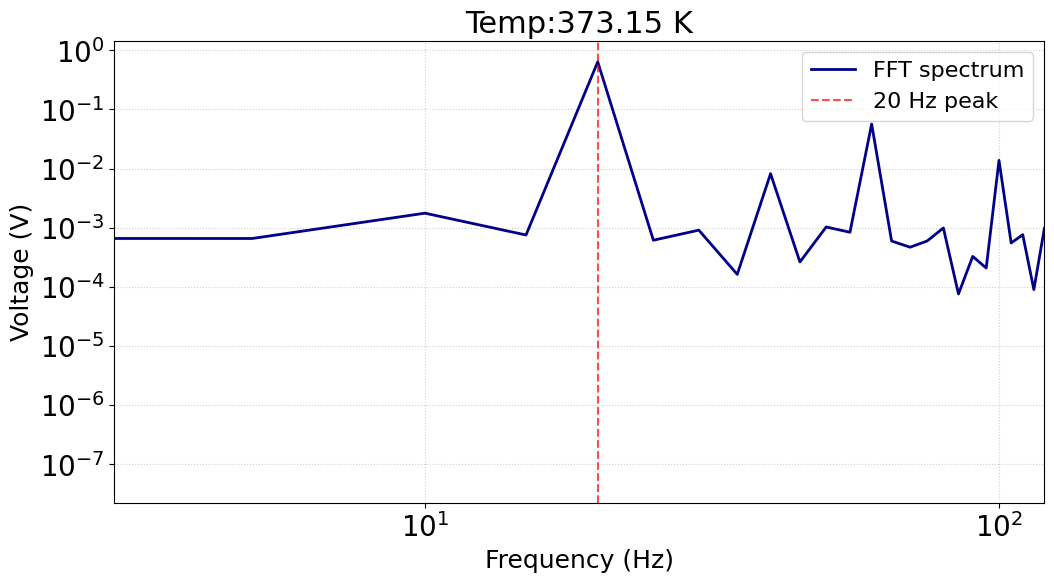

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


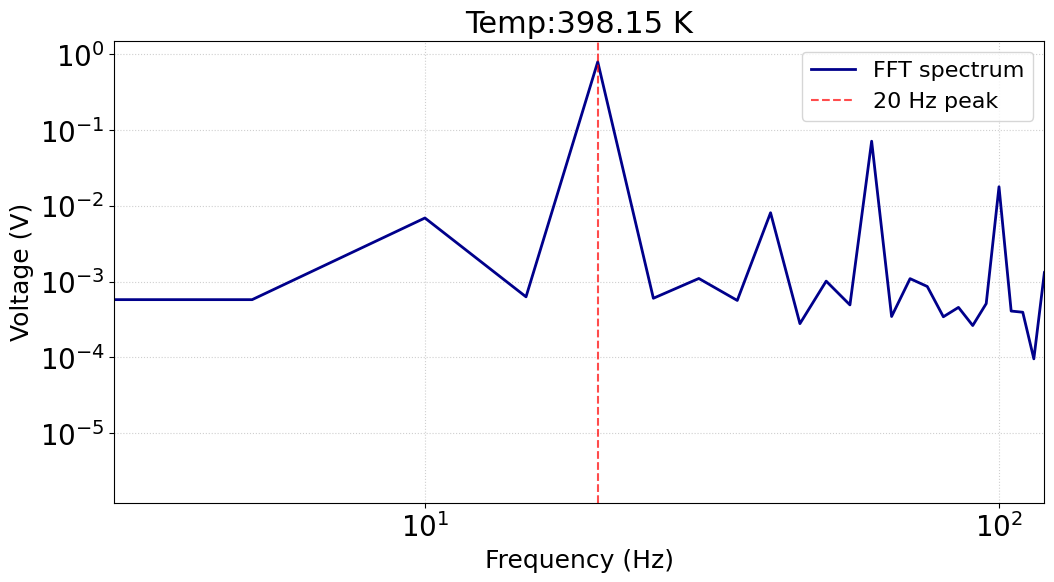

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


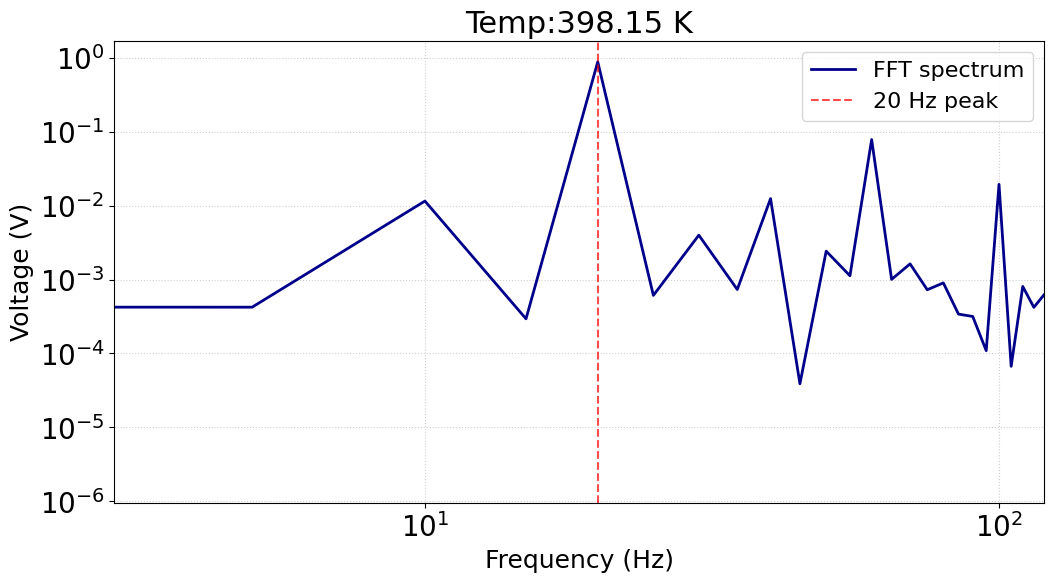

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


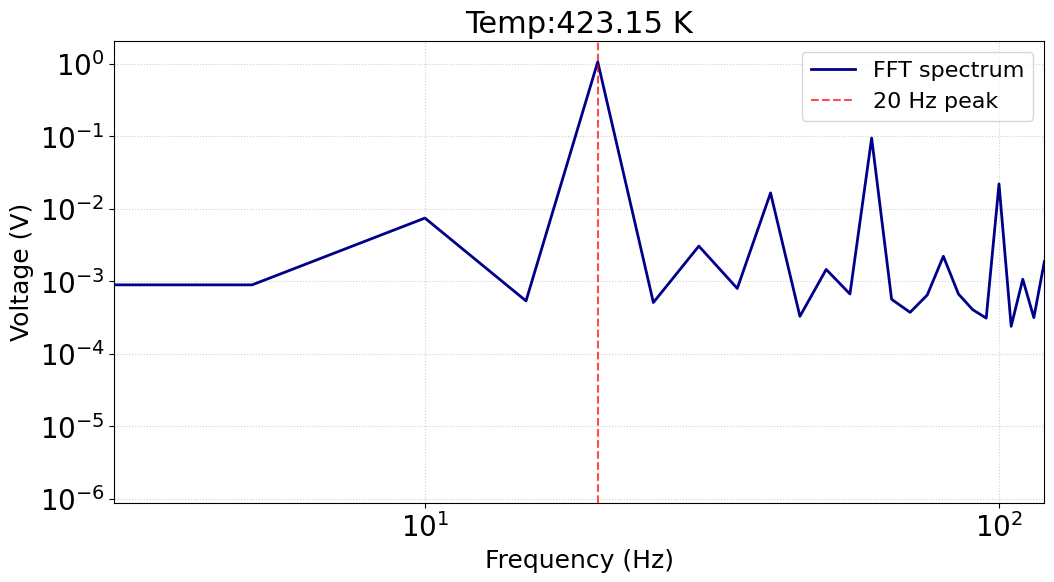

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


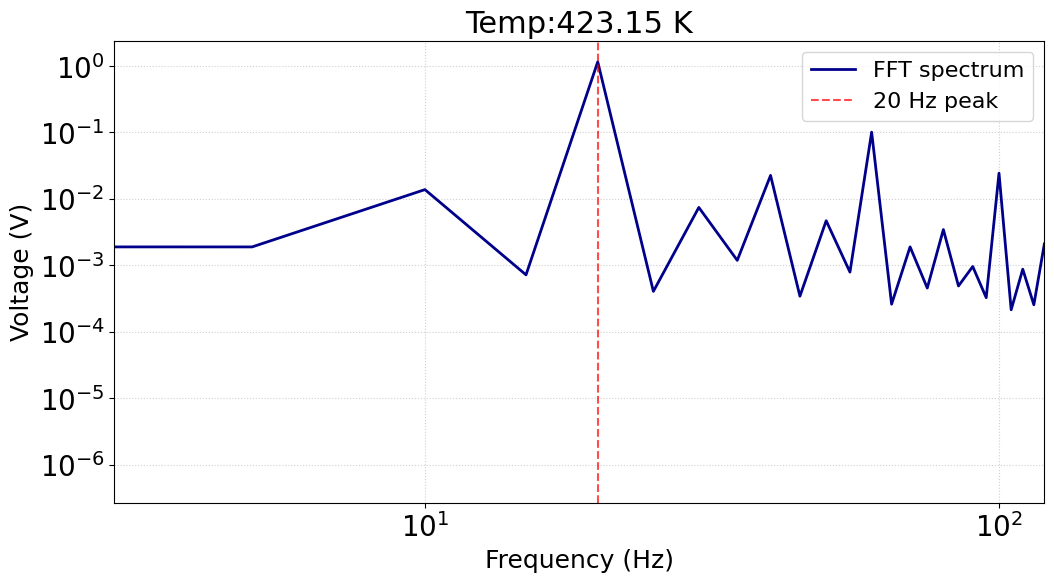

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


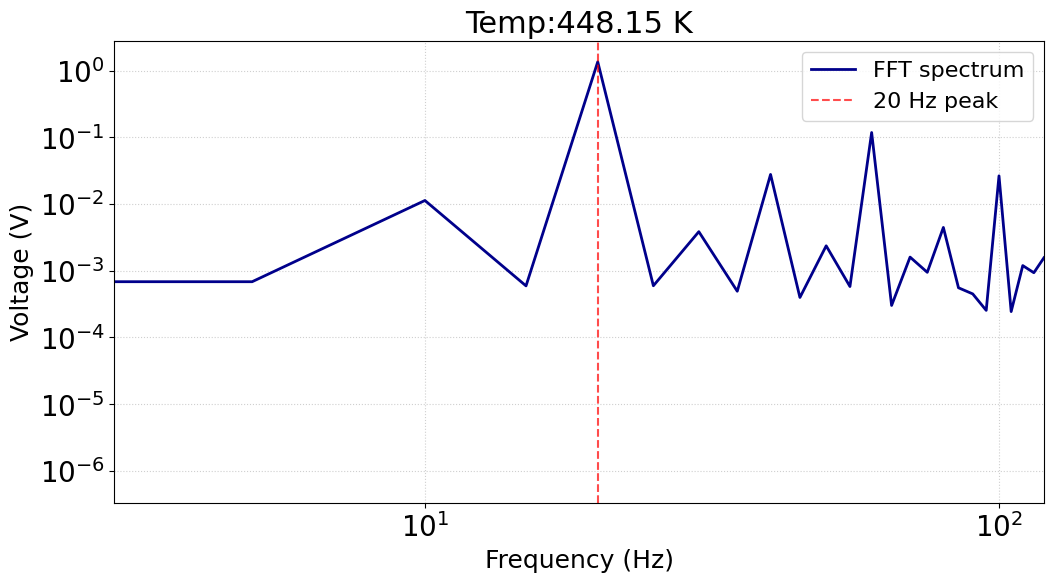

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


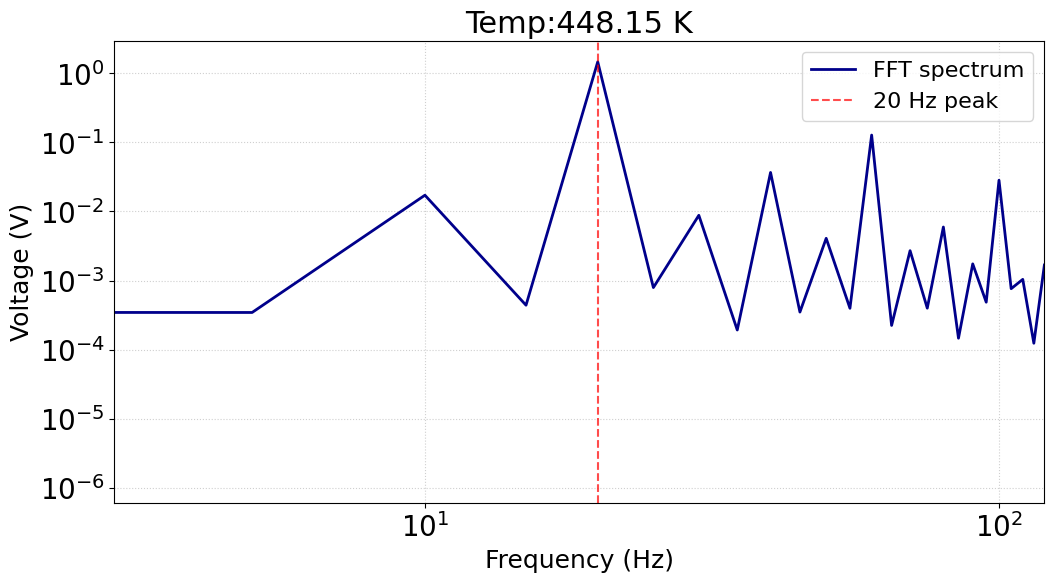

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


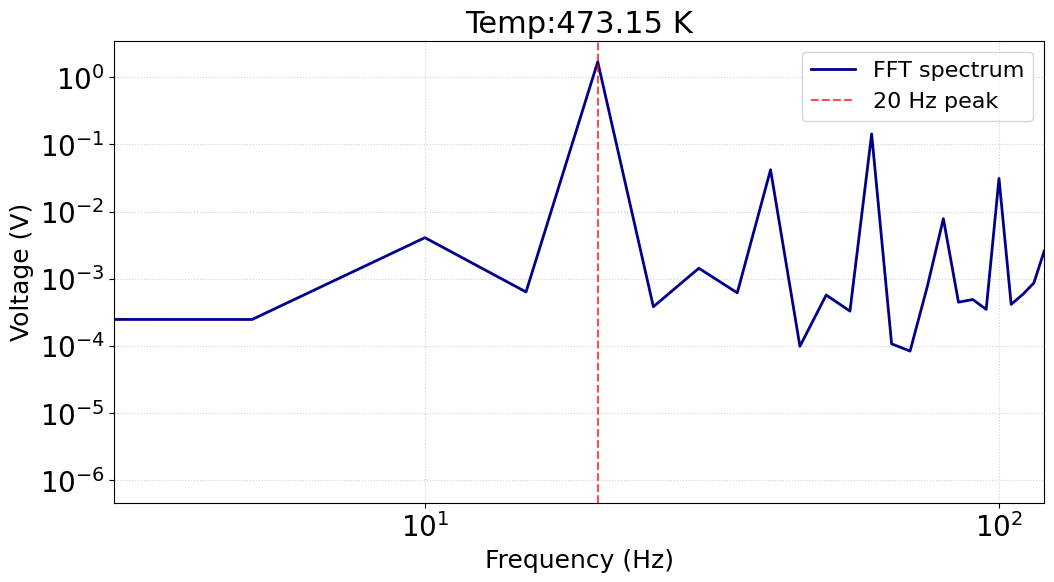

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


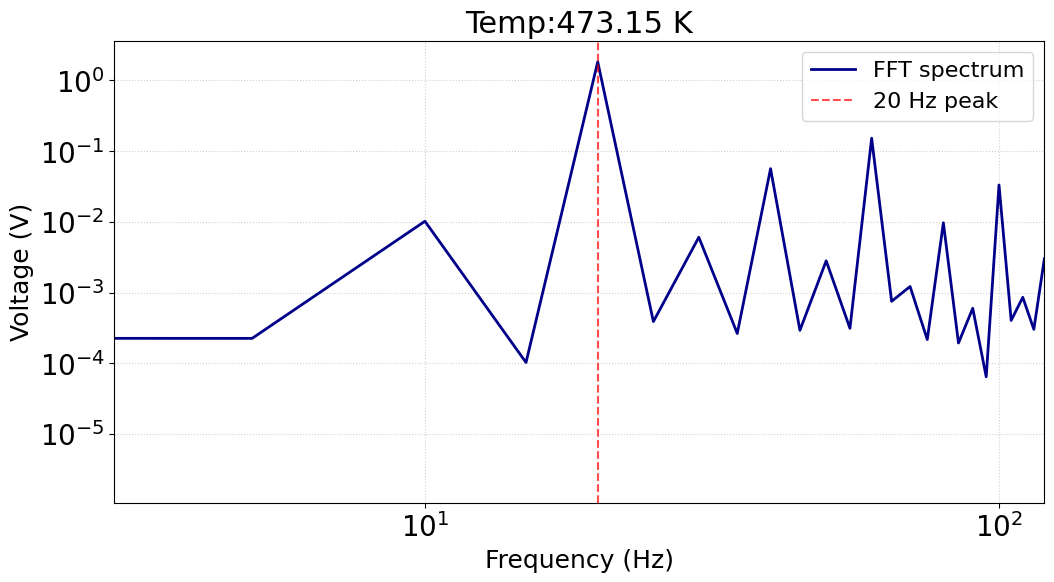

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


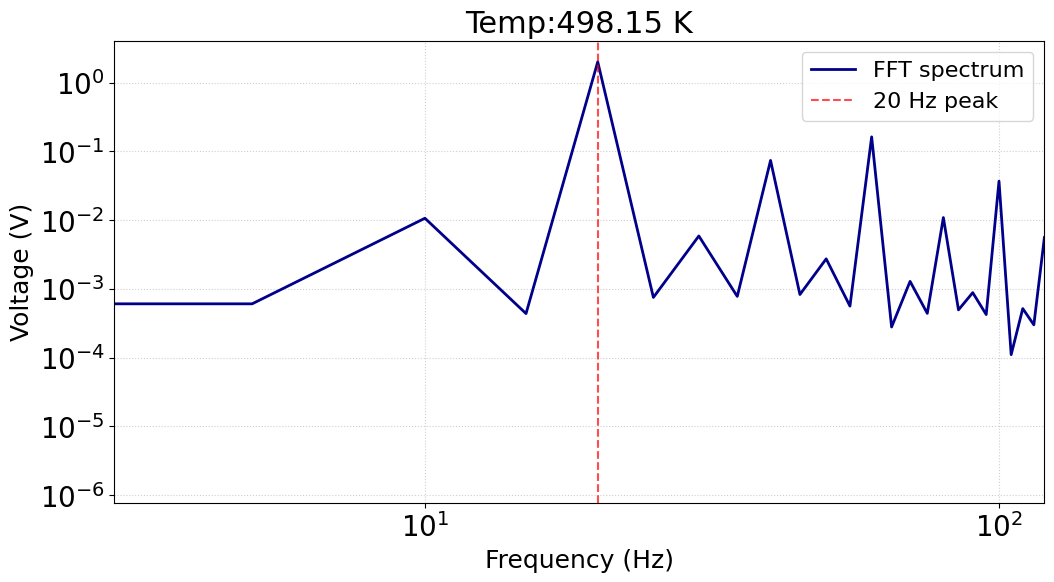

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


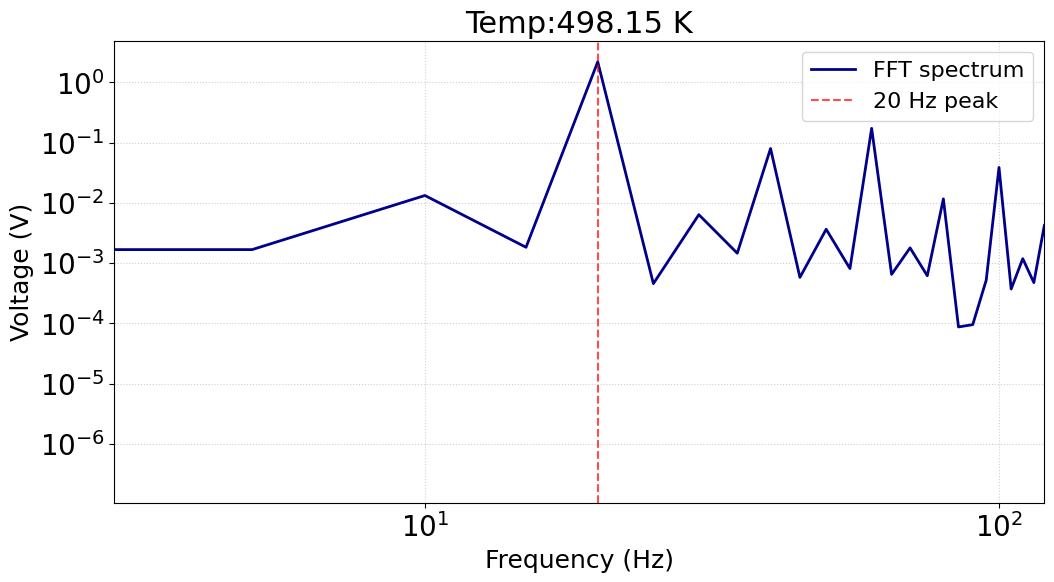

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


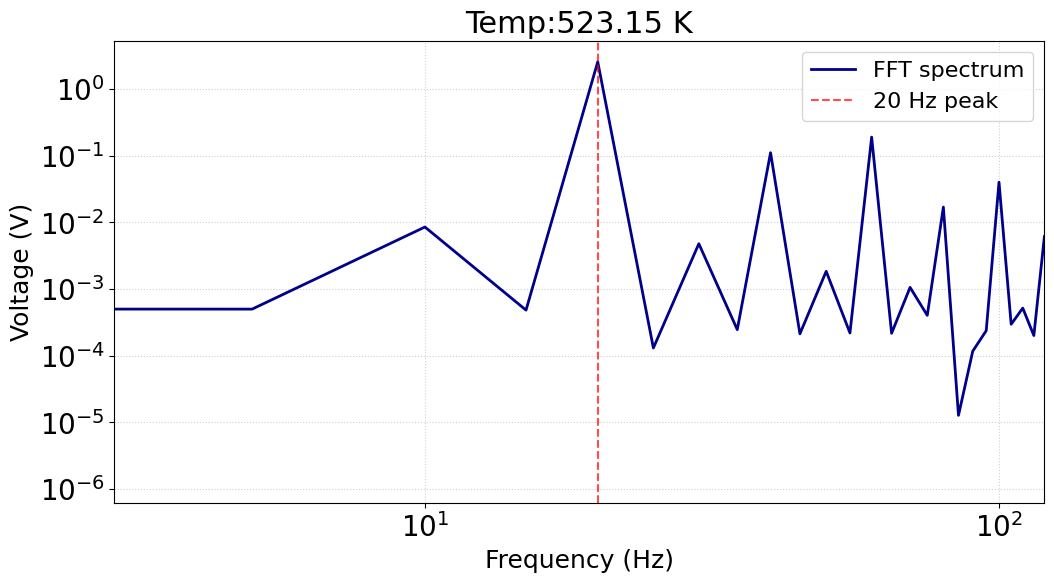

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


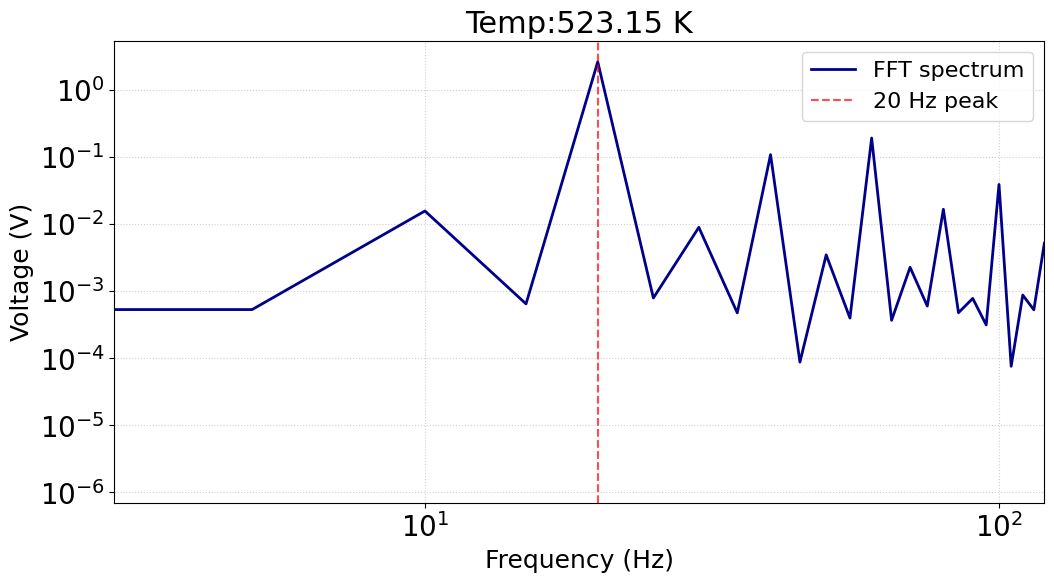

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


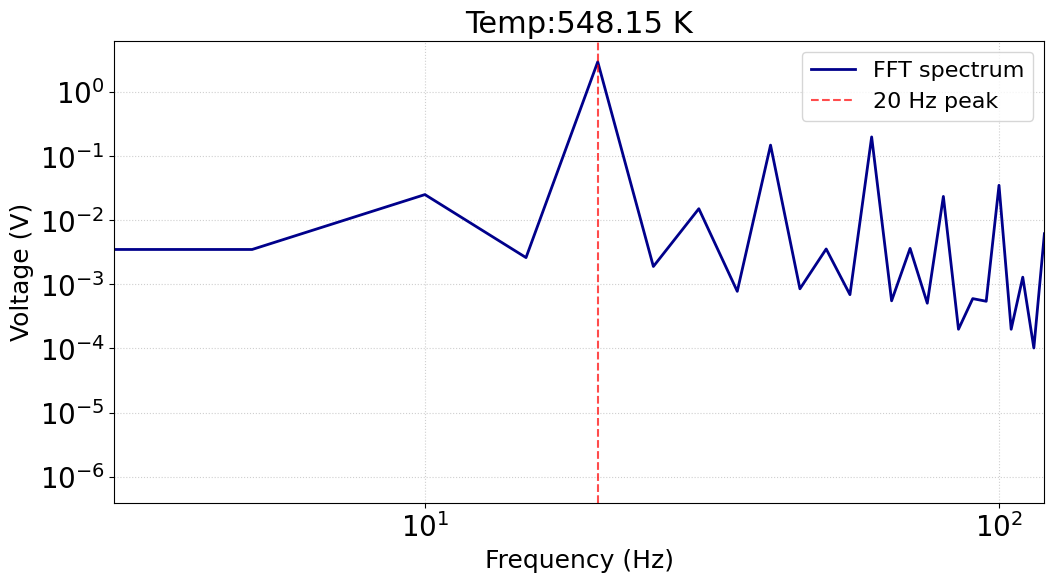

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


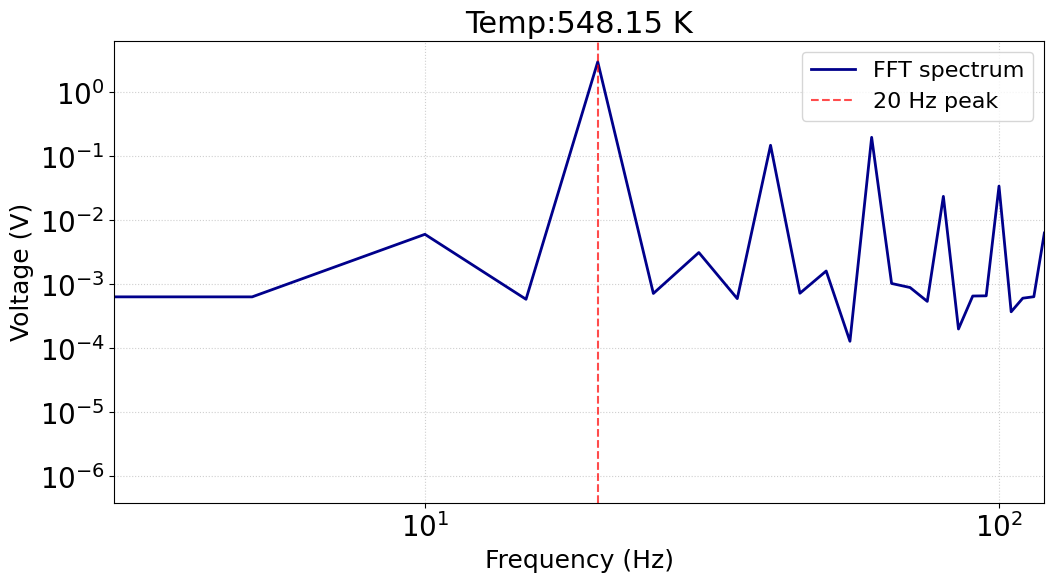

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


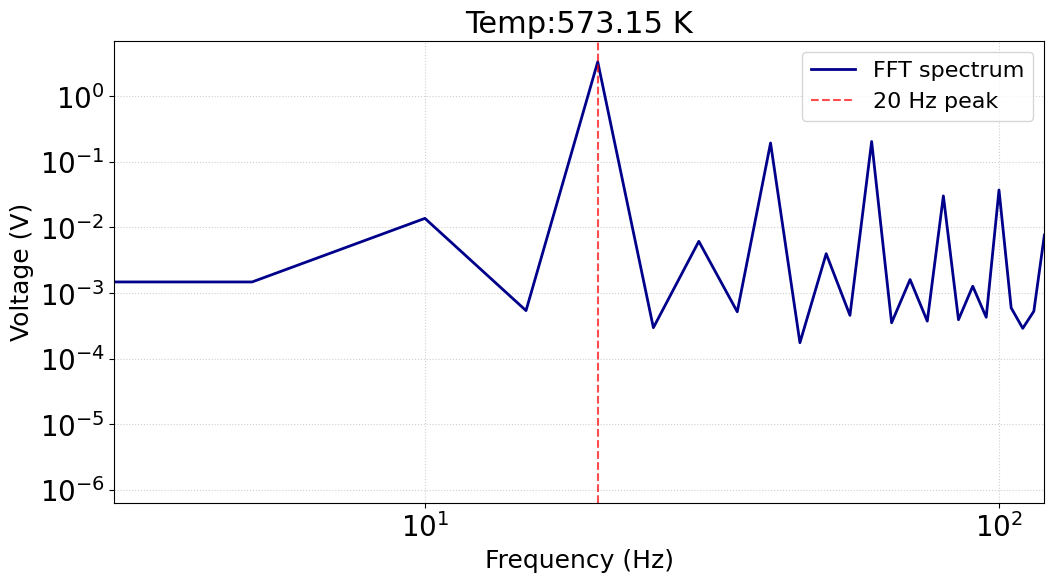

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


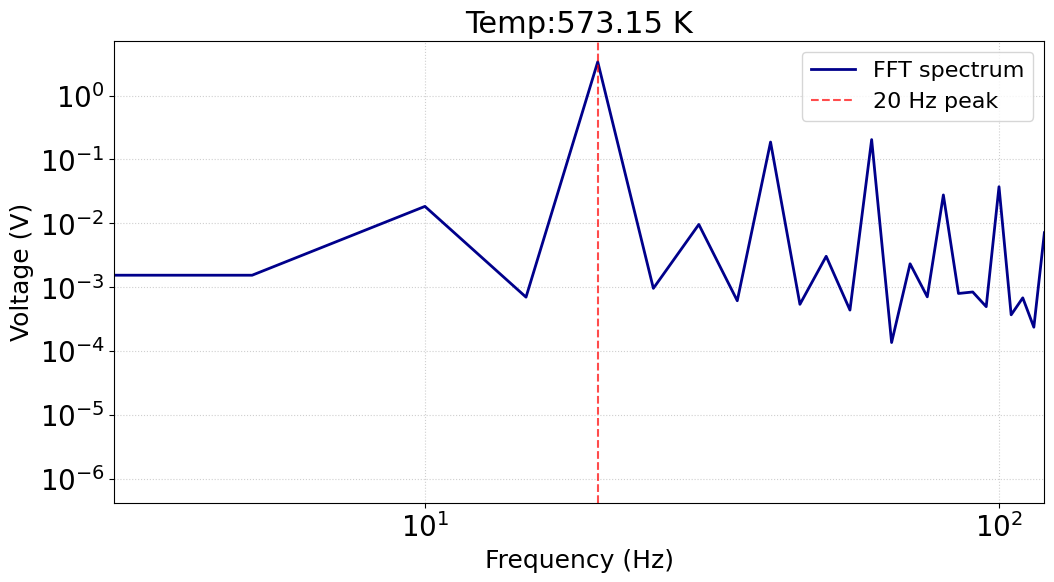

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


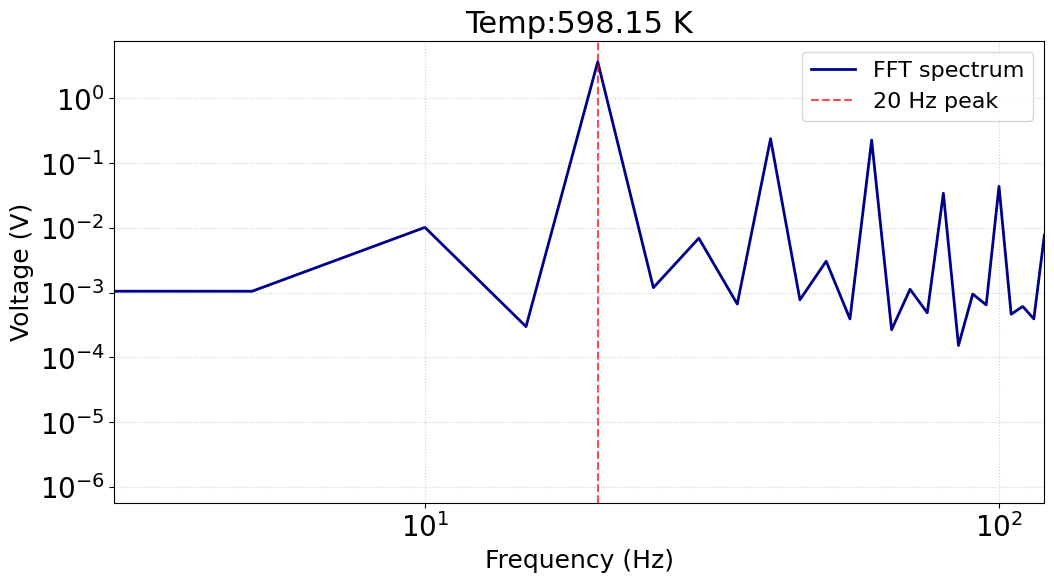

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


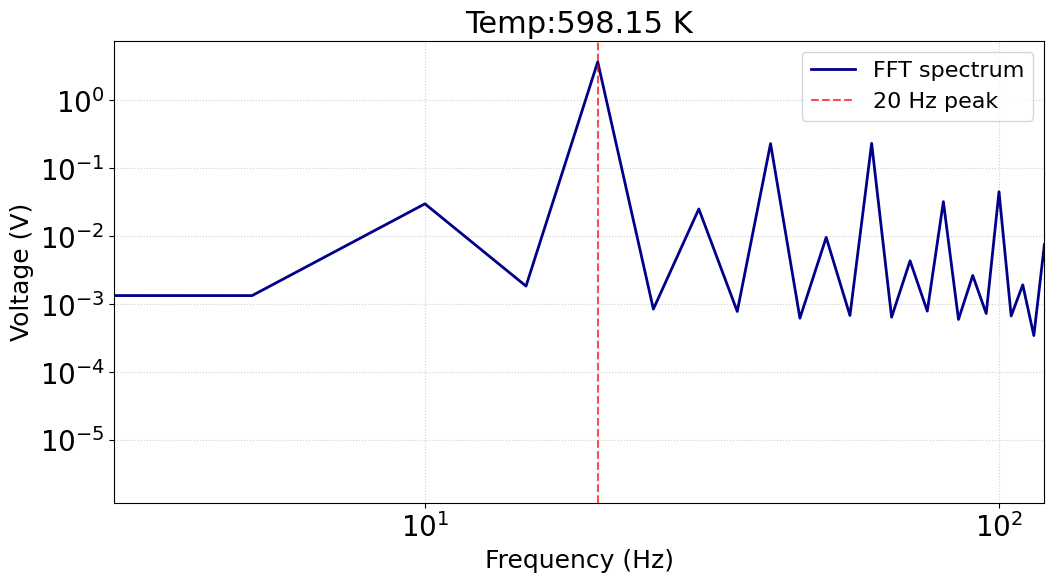

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


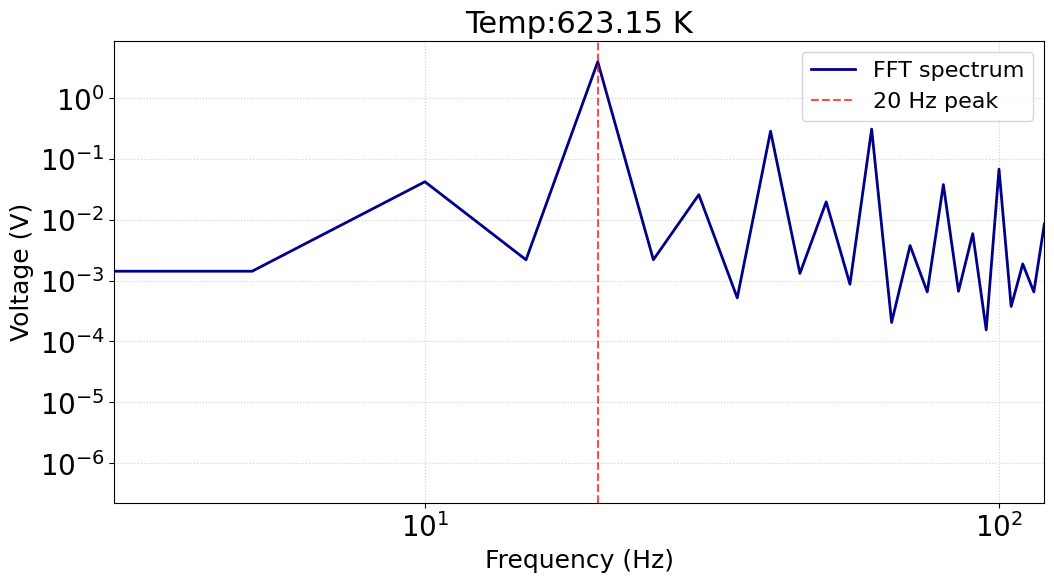

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


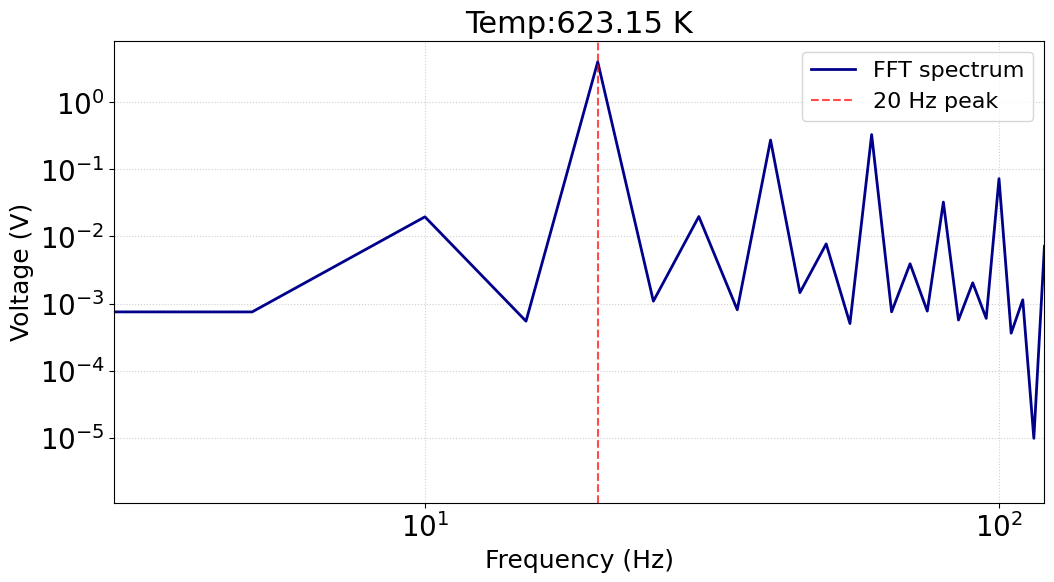

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


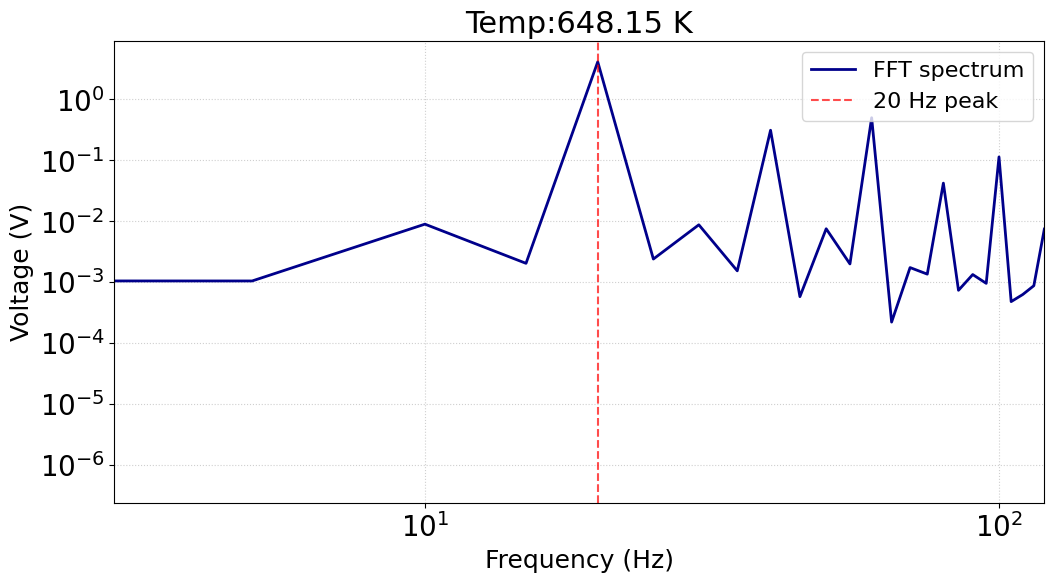

/tmp/ipykernel_4636/1058088387.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 120)
/tmp/ipykernel_4636/1058088387.py:85: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(file_fig_fft, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


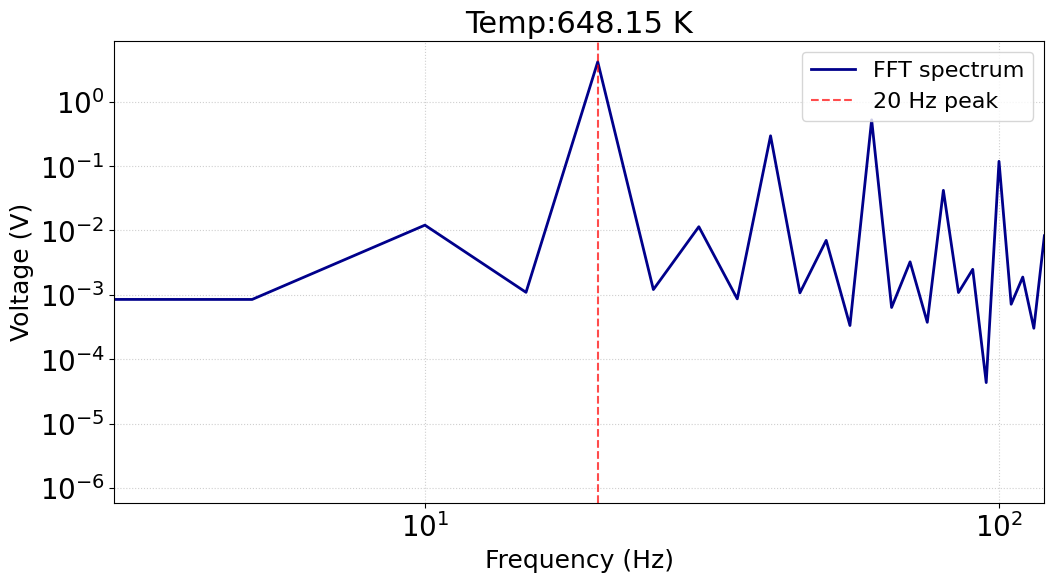

Processamento das FFTs com validação de metadados concluído!


In [ ]:
# ==========================================
# CÉLULA ADICIONAL: ANÁLISE NO DOMÍNIO DA FREQUÊNCIA (FFT) COM METADADOS REAIS
# ==========================================

import io
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

print("Iniciando a geração dos espectros de frequência (FFT) extraindo metadados do hardware...")

for i in range(quantidade_arquivos):
    try:
        nome_arquivo = df_index['Arquivo'].iloc[i]
        url = 'https://raw.githubusercontent.com/profdanielrsousa/datasets_mackenzie/refs/heads/main/' + nome_arquivo + 'CSV'

        try:
            # 1. Baixa o arquivo completo como texto na memória (faz apenas uma requisição web)
            resposta = requests.get(url)
            resposta.raise_for_status()
            conteudo_texto = resposta.text

            # 2. EXTRAÇÃO AUTOMÁTICA E RÍGIDA DO METADADO DO OSCILOSCÓPIO
            dt = None
            for linha in conteudo_texto.splitlines()[:15]:  # Varre apenas as linhas do cabeçalho
                if "Sample Interval" in linha:
                    # Extrai o valor após a vírgula (ex: 1.6e-06) e converte para float
                    dt = float(linha.split(',')[1])
                    break

            # Caso ocorra algum erro inesperado na leitura do cabeçalho, define o fallback seguro
            if dt is None:
                dt = 1.6e-06
                print(f"Aviso: Cabeçalho não encontrado no arquivo {nome_arquivo}. Usando padrão de 1.6 µs.")

            # 3. Carrega os dados numéricos no Pandas a partir do texto já baixado
            df = pd.read_csv(io.StringIO(conteudo_texto), header=None, names=['tempo', 'ch1', 'ch1_pico'], skiprows=16, nrows=125000)

        except Exception as e:
            print(f"Erro ao processar/baixar o arquivo {nome_arquivo}: {e}")
            continue

        # Extrair os vetores como arrays do NumPy
        t = df['tempo'].to_numpy()
        y = df['ch1'].to_numpy()

        # Configurações de frequência baseadas no intervalo real do hardware obtido dinamicamente
        fs = 1.0 / dt
        N = len(y)

        # Calcular a FFT
        fft_valores = np.fft.rfft(y)
        frequencias = np.fft.rfftfreq(N, d=dt)
        amplitudes = 2.0 * np.abs(fft_valores) / N

        # Identificar a temperatura correspondente em Kelvin
        temp_k = df_index['Temperatura Corpo Negro (°C)'].iloc[i] + 273.15

        # Configuração do gráfico
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.plot(frequencias, amplitudes, color='darkblue', linewidth=2, label='FFT spectrum')
        ax.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='20 Hz peak')

        # Zoom na região de interesse
        ax.set_xlim(0, 120)

        # Título dinâmico indicando a precisão do intervalo utilizado
        titulo_fft = f"Temp:{temp_k:.2f} K"
        ax.set_title(titulo_fft, fontsize=22)
        ax.set_xlabel('Frequency (Hz)', fontsize=18)
        ax.set_ylabel('Voltage (V)', fontsize=18)
        ax.grid(True, which='both', linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=16)

        ax.minorticks_on()
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

        # Salvar gráfico
        file_fig_fft = f"{i}_T{temp_k:.2f}_FFT.png"
        plt.savefig(file_fig_fft, bbox_inches='tight')
        plt.show()

    except IndexError:
        print('Fim do processamento por limite de índice.')

print("Processamento das FFTs com validação de metadados concluído!")